In [1]:
from stopping_power_analysis import StoppingPowerAnalysis

import numpy as np
import matplotlib.pyplot as plt
from ase.visualize import view

In [2]:
# this one is old data with a (1,2,2) Al supercell
data_directory = "/Users/brynlloyd/Developer/Coding/Python/dft/gpaw/my_own_stopping/data/small_unitcell/"
# data_directory = "/Users/brynlloyd/Developer/Coding/Python/dft/gpaw/my_own_stopping/data/small_every_timestep/"

# (2,2,2) supercell with the code that prevents charge transfer in the inital dft simulation
# data_directory = "/Users/brynlloyd/Developer/Coding/Python/dft/gpaw/my_own_stopping/data/larger_unitcell/"

# (2,2,2) supercell WITHOUT the code that prevents charge transfer in the inital dft simulation
# data_directory = "/Users/brynlloyd/Developer/Coding/Python/dft/gpaw/my_own_stopping/data/single_calculation/"

# (3,2,2) supercell without fermi smearing - honestly idk how this even converged
# data_directory = "/Users/brynlloyd/Developer/Coding/Python/dft/gpaw/my_own_stopping/data/322_supercell_poorDFT"

# (3,2,2) supercell with 0.02eV fermi smearing. Proton initial position is a lot closer to supercell
# data_directory = "/Users/brynlloyd/Developer/Coding/Python/dft/gpaw/my_own_stopping/data/322_supercell"

# (3,2,2) supercell with 0.02eV fermi smearing. No vacuum around supercell + pbc's
# data_directory = "/Users/brynlloyd/Developer/Coding/Python/dft/gpaw/my_own_stopping/data/322_supercell"

In [3]:
analysis = StoppingPowerAnalysis(data_directory)

/Users/brynlloyd/Developer/Coding/Python/dft/gpaw/my_own_stopping/data/small_unitcell/
{
    "40 keV": [
        "aluminium_fcc_ek40k_step10.gpw",
        "aluminium_fcc_ek40k_step20.gpw",
        "aluminium_fcc_ek40k_step30.gpw",
        "aluminium_fcc_ek40k_step40.gpw",
        "aluminium_fcc_ek40k_step50.gpw",
        "aluminium_fcc_ek40k_step60.gpw",
        "aluminium_fcc_ek40k_step70.gpw",
        "aluminium_fcc_ek40k_step80.gpw",
        "aluminium_fcc_ek40k_step90.gpw"
    ],
    "20 keV": [
        "aluminium_fcc_ek20k_step10.gpw",
        "aluminium_fcc_ek20k_step20.gpw",
        "aluminium_fcc_ek20k_step30.gpw",
        "aluminium_fcc_ek20k_step40.gpw",
        "aluminium_fcc_ek20k_step50.gpw",
        "aluminium_fcc_ek20k_step60.gpw",
        "aluminium_fcc_ek20k_step70.gpw",
        "aluminium_fcc_ek20k_step80.gpw",
        "aluminium_fcc_ek20k_step90.gpw"
    ]
}


/Users/brynlloyd/Developer/Coding/Python/dft/gpaw/my_own_stopping/env/lib/python3.9/site-packages/gpaw/wavefunctions/base.py:572: ComplexWarning: Casting complex values to real discards the imaginary part
  kpt.projections.matrix.array[:] = P_nI


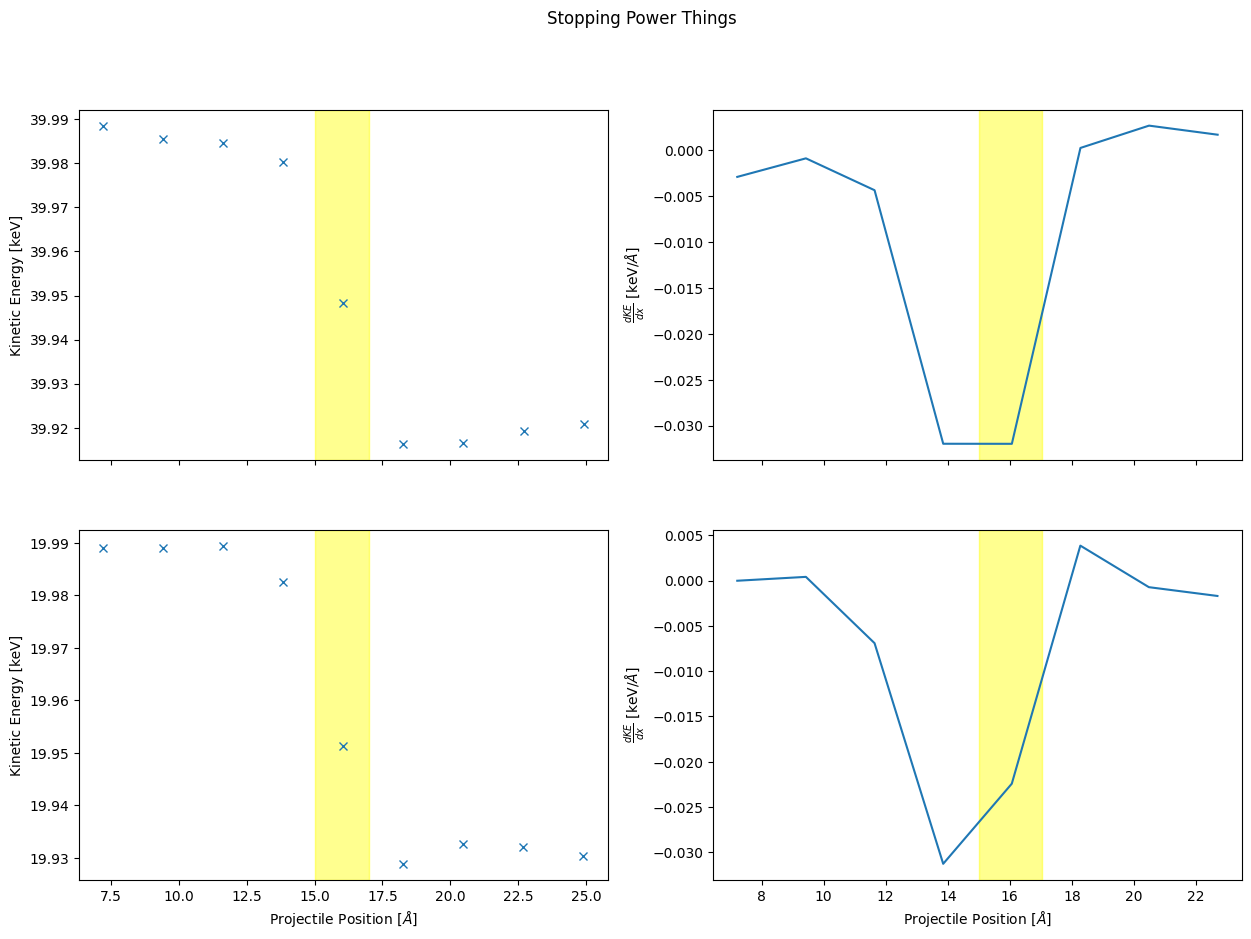

In [4]:
analysis.plot_stopping_data()

In [ ]:
# MONKEY PATCHING
# FUNCTION TO COMPARE STOPPING POWER AT MULTIPLE ENERGIES TO GEANT4 PREDICTIONS
"""
THIS FUNCTION WILL ONLY WORK FOR A SINGLE TRAJECTORY
TO COMPARE DIFFERENT TRAJECTORIES, FUNCTION PROBABLY NEEDS TO BE A METHOD OF A LARGER CLASS
"""

# from /Users/brynlloyd/Documents/PhD/coding/stopping_models/dftgeant_analysis/geant4_analysis.ipynb
GEANT4_ENERGIES = np.arange(5, 251, 5)
GEANT4_STOPPING_POWERS = np.array([8.41642534,  8.39403791,  9.61722966, 10.47531744, 11.12587244, 11.66446394, 12.3387949 , 12.60404201, 12.70727751, 12.74141819, 12.84432534, 12.96025452, 12.82696325, 12.74379889, 12.69518111, 12.56137771, 12.41201793, 12.33257865, 12.21160185, 12.09496251, 12.01462424, 11.898194, 11.77969121, 11.66621298, 11.50000087, 11.37880456, 11.31399968, 11.22186803, 11.06282411, 10.93625158, 10.81506187, 10.75385659, 10.58539531, 10.49800502, 10.48398759, 10.4024316, 10.27643047, 10.19540826, 10.01933624, 9.98213156, 9.99531111, 9.7817623 , 9.66781196,  9.78197921, 9.71504747, 9.51892708,  9.52356048,  9.36827356,  9.36659151,  9.22948771])


def new_plot_stopping_curve(self):
    ###############
    # CREATE PLOT #
    ###############

    print("hello world")

    fig,ax = plt.subplots(figsize=(15,5))
    fig.suptitle("Ehrenfest Dynamics stopping power comparison to Monte Carlo")
    ax.set_xlabel("Initial Projectile KE [keV]")
    ax.set_ylabel(r"Stopping Power [keV / $\AA$]")

    ####################
    # PLOT GEANT4 DATA #
    ####################

    ax.plot(GEANT4_ENERGIES, GEANT4_STOPPING_POWERS)

    #####################################
    # EXTRACT EHRENFEST STOPPING POWERS #
    #####################################

    # TODO: havent written a function that can extract stopping power from the new simulations
    ehrenfest_energies = np.array([])
    ehrenfest_stopping_powers = np.array([])
    for energy in self.atoms_dict.keys():
        initial_energy, stopping_power = self.extract_stopping_power(energy)
        ehrenfest_energies = np.append(ehrenfest_energies, initial_energy, axis=-1)
        ehrenfest_stopping_powers = np.append(ehrenfest_stopping_power, stopping_power, axis=-1)


    #######################
    # PLOT EHRENFEST DATA #
    #######################

    ax.plot(ehrenfest_energies, ehrenfest_stopping_powers, "-x")



StoppingPowerAnalysis.plot_stopping_curve = new_plot_stopping_curve

hello world


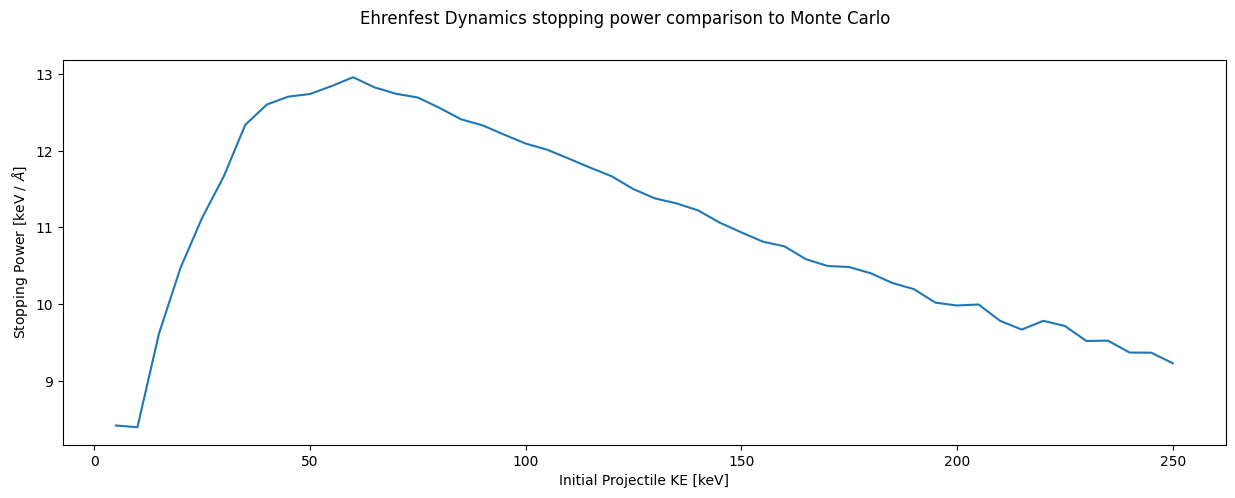

In [6]:
analysis.plot_stopping_curve()